## Prepare Google Colab Environment

In [1]:
import os

#@title Install Packages {display-mode:"form"}
INSTALL_PACKAGES = False #@param {type:"boolean"}

# Check if packages have already been installed in this session to prevent re-installation
if INSTALL_PACKAGES and not os.environ.get('PYPSA_PACKAGES_INSTALLED'):
  !pip install pypsa pypsa[excel] folium mapclassify cartopy
  os.environ['PYPSA_PACKAGES_INSTALLED'] = 'true'
elif not INSTALL_PACKAGES:
  print("Skipping package installation.")
else:
  print("PyPSA packages are already installed for this session.")

Skipping package installation.


# Exercise 1.1

**Objective:**

Programatically build a PyPSA network, define the model’s constraints, solve it, and review the results.

**Diagram**

<img src="https://raw.githubusercontent.com/PriyeshGosai/pypsa-meets-earth-lab-2025/main/img/example_1_img.png" alt="Example 1" width="50%">

In [2]:
import pypsa
import pandas as pd
import numpy as np
pypsa.options.api.new_components_api = True

snapshots_df = pd.date_range('2025-01-01 00:00', '2025-12-31 23:00', freq='h')
load_profile = np.random.rand(len(snapshots_df)) * 100

n = pypsa.Network()
n.set_snapshots(snapshots_df)
n.add('Carrier',['gas','AC'])
n.add('Bus','Location',carrier = 'AC')

n.add('Load',
      'Load A',
      bus = 'Location',
      p_set = load_profile,
      carrier = 'gas')

n.add('Generator',
      'Generator A',
      bus = 'Location',
      p_nom = 10,
      marginal_cost = 1,
      p_nom_extendable = True)



In [3]:
n.generators.static.p_nom_opt

name
Generator A    0.0
Name: p_nom_opt, dtype: float64

In [4]:
n.generators.static

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
Generator A,Location,PQ,,10.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0


In [5]:
n.loads.static

,bus,carrier,type,p_set,q_set,sign,active
name,,,,,,,
Load A,Location,gas,,0.0,0.0,-1.0,True


In [6]:
n.buses.static

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
name,,,,,,,,,,,,,
Location,1.0,,0.0,0.0,AC,,,1.0,0.0,inf,PQ,,


In [7]:
n.optimize()

C:\Users\PriyeshGosai\AppData\Local\Temp\ipykernel_63428\1261279110.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 8761 primals, 26281 duals
Objective: 4.39e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [8]:
n.generators.static

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
Generator A,Location,Slack,,10.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,99.972846


In [9]:
n.objective_constant

0.0

In [10]:
n.buses.dynamic.marginal_price.sum()

name
Location    8760.0
dtype: float64

In [11]:
n.snapshot_weightings

,objective,stores,generators
snapshot,,,
2025-01-01 00:00:00,1.0,1.0,1.0
2025-01-01 01:00:00,1.0,1.0,1.0
2025-01-01 02:00:00,1.0,1.0,1.0
2025-01-01 03:00:00,1.0,1.0,1.0
2025-01-01 04:00:00,1.0,1.0,1.0
...,...,...,...
2025-12-31 19:00:00,1.0,1.0,1.0
2025-12-31 20:00:00,1.0,1.0,1.0
2025-12-31 21:00:00,1.0,1.0,1.0


In [12]:
n.objective

439101.02249768726

In [13]:
for key in n.buses.dynamic:
    print(key)

v_mag_pu_set
p
q
v_mag_pu
v_ang
marginal_price


In [14]:
n.loads

'Load' Components
-----------------
Attached to PyPSA Network 'Unnamed Network'
Components: 1

In [15]:
n.objective

439101.02249768726

# Exercise 1.2

In this example, we will use an example network distributed with PyPSA to observe more complex features. 



## Meshed AC–DC Network Optimisation in PyPSA

This example demonstrates how to optimise a **meshed AC–DC network** in PyPSA.  
The network contains a **3-node AC system** connected via **AC–DC converters** to a **3-node DC system**.  
There is also a **point-to-point DC connection** represented using the `Link` component.

Reference example:  
https://docs.pypsa.org/latest/examples/ac-dc-lopf/


In [16]:
import pypsa
pypsa.options.api.new_components_api = True

# Fix for pandas 2.3.0 StringDtype incompatibility with PyPSA plotting
import pandas as pd
pd.options.future.infer_string = False

network = pypsa.examples.ac_dc_meshed()

INFO:pypsa.network.io:Retrieving network data from https://github.com/PyPSA/PyPSA/raw/v1.1.2/examples/networks/ac-dc-meshed/ac-dc-meshed.nc.
INFO:pypsa.network.io:Imported network 'AC-DC-Meshed' has buses, carriers, generators, global_constraints, lines, links, loads


In [17]:
network.carriers.static

,co2_emissions,color,nice_name,max_growth,max_relative_growth,marginal_cost,efficiency,capital_cost
name,,,,,,,,
gas,0.24,red,,inf,0.0,0.0,1.0,0.0
wind,0.00,blue,,inf,0.0,0.0,1.0,0.0
battery,0.00,green,,inf,0.0,0.0,1.0,0.0
load,0.00,black,,inf,0.0,NaN,NaN,NaN
AC,0.00,orange,,inf,0.0,NaN,NaN,NaN
DC,0.00,purple,,inf,0.0,NaN,NaN,NaN


In [18]:
network.carriers.static

,co2_emissions,color,nice_name,max_growth,max_relative_growth,marginal_cost,efficiency,capital_cost
name,,,,,,,,
gas,0.24,red,,inf,0.0,0.0,1.0,0.0
wind,0.00,blue,,inf,0.0,0.0,1.0,0.0
battery,0.00,green,,inf,0.0,0.0,1.0,0.0
load,0.00,black,,inf,0.0,NaN,NaN,NaN
AC,0.00,orange,,inf,0.0,NaN,NaN,NaN
DC,0.00,purple,,inf,0.0,NaN,NaN,NaN


In [19]:
network.global_constraints.static

,type,investment_period,bus,carrier_attribute,sense,constant,mu
name,,,,,,,
co2_limit,primary_energy,NaN,,co2_emissions,<=,1000.0,0.0


In [20]:
network.generators.static.efficiency

name
Manchester Wind    1.000000
Manchester Gas     0.350026
Norway Wind        1.000000
Norway Gas         0.356836
Frankfurt Wind     1.000000
Frankfurt Gas      0.351666
Name: efficiency, dtype: float64

In [21]:
network.generators.static.p_nom_extendable

name
Manchester Wind    True
Manchester Gas     True
Norway Wind        True
Norway Gas         True
Frankfurt Wind     True
Frankfurt Gas      True
Name: p_nom_extendable, dtype: bool

In [22]:
network.generators.static

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
Manchester Wind,Manchester,PQ,,80.0,0.0,True,100.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Manchester Gas,Manchester,PQ,,50000.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Norway Wind,Norway,PQ,,100.0,0.0,True,100.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Norway Gas,Norway,PQ,,20000.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Frankfurt Wind,Frankfurt,PQ,,110.0,0.0,True,100.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Frankfurt Gas,Frankfurt,PQ,,80000.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0


In [23]:
# line_color = network.lines.static.bus0.map(network.buses.static.carrier).map(
#     lambda ct: "r" if ct == "DC" else "b"
# ).astype(object) 

# network.plot.explore(
#     # line_color=line_color,
#     link_color="c",
#     jitter=0.4,
# )

In [24]:
network.determine_network_topology()


PyPSA Network 'AC-DC-Meshed'
----------------------------
Components:
 - Bus: 9
 - Carrier: 6
 - Generator: 6
 - GlobalConstraint: 1
 - Line: 7
 - Link: 4
 - Load: 6
 - SubNetwork: 4
Snapshots: 10

In [25]:
network.snapshots

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq=None)

In [26]:
network.buses.static

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,country
name,,,,,,,,,,,,,,
London,380.0,,-0.13,51.50,AC,,,1.0,0.0,inf,PQ,,0,UK
Norwich,380.0,,1.30,52.60,AC,,,1.0,0.0,inf,PQ,,0,UK
Norwich DC,200.0,,1.30,52.50,DC,,,1.0,0.0,inf,Slack,,1,UK
Manchester,380.0,,-2.20,53.47,AC,,,1.0,0.0,inf,Slack,Manchester Wind,0,UK
Bremen,380.0,,8.80,53.08,AC,,,1.0,0.0,inf,PQ,,2,DE
Bremen DC,200.0,,8.80,52.98,DC,,,1.0,0.0,inf,PQ,,1,DE
Frankfurt,380.0,,8.70,50.12,AC,,,1.0,0.0,inf,Slack,Frankfurt Wind,2,DE
Norway,380.0,,10.75,60.00,AC,,,1.0,0.0,inf,Slack,Norway Wind,3,NO
Norway DC,200.0,,10.75,60.00,DC,,,1.0,0.0,inf,PQ,,1,NO


In [27]:
network.generators.static

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
Manchester Wind,Manchester,Slack,,80.0,0.0,True,100.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Manchester Gas,Manchester,PQ,,50000.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Norway Wind,Norway,Slack,,100.0,0.0,True,100.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Norway Gas,Norway,PQ,,20000.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Frankfurt Wind,Frankfurt,Slack,,110.0,0.0,True,100.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Frankfurt Gas,Frankfurt,PQ,,80000.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0


In [28]:
network.generators.dynamic.p_max_pu

name,Manchester Wind,Frankfurt Wind,Norway Wind
snapshot,,,
2015-01-01 00:00:00,0.930020,0.559078,0.974583
2015-01-01 01:00:00,0.485748,0.752910,0.481290
2015-01-01 02:00:00,0.233692,0.123465,0.407226
2015-01-01 03:00:00,0.257604,0.966677,0.599965
2015-01-01 04:00:00,0.626906,0.859008,0.524468
2015-01-01 05:00:00,0.603598,0.526154,0.009693
2015-01-01 06:00:00,0.678908,0.077893,0.220453
2015-01-01 07:00:00,0.361303,0.059023,0.823919
2015-01-01 08:00:00,0.621604,0.248554,0.556230


In [29]:
network.lines.static

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
0,London,Manchester,,0.796878,0.000000,0.0,0.0,40000.0,0.0,True,...,-inf,inf,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Manchester,Norwich,,0.391560,0.000000,0.0,0.0,40000.0,0.0,True,...,-inf,inf,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Bremen DC,Norwich DC,,0.000000,0.212604,0.0,0.0,40000.0,0.0,True,...,-inf,inf,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Norwich DC,Norway DC,,0.000000,0.486164,0.0,0.0,40000.0,0.0,True,...,-inf,inf,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Norway DC,Bremen DC,,0.000000,0.428727,0.0,0.0,40000.0,0.0,True,...,-inf,inf,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Norwich,London,,0.238800,0.000000,0.0,0.0,40000.0,0.0,True,...,-inf,inf,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Bremen,Frankfurt,,0.400000,0.000000,0.0,0.0,40000.0,0.0,True,...,-inf,inf,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
network.links.static

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,delay,cyclic_delay,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
Norwich Converter,Norwich,Norwich DC,,DC,1.0,True,0,inf,1000.0,0.0,...,0,1,0,NaN,NaN,NaN,NaN,0,True,0.0
Norway Converter,Norway,Norway DC,,DC,1.0,True,0,inf,1000.0,0.0,...,0,1,0,NaN,NaN,NaN,NaN,0,True,0.0
Bremen Converter,Bremen,Bremen DC,,DC,1.0,True,0,inf,1000.0,0.0,...,0,1,0,NaN,NaN,NaN,NaN,0,True,0.0
DC link,London,Bremen,,DC,1.0,True,0,inf,1000.0,0.0,...,0,1,0,NaN,NaN,NaN,NaN,0,True,0.0


In [31]:
network.loads.static

,bus,carrier,type,p_set,q_set,sign,active
name,,,,,,,
London,London,load,,0.0,0.0,-1.0,True
Frankfurt,Frankfurt,load,,0.0,0.0,-1.0,True
Norway,Norway,load,,0.0,0.0,-1.0,True
Norwich,Norwich,load,,0.0,0.0,-1.0,True
Bremen,Bremen,load,,0.0,0.0,-1.0,True
Manchester,Manchester,load,,0.0,0.0,-1.0,True


In [32]:
network.loads.dynamic.p_set

name,London,Norwich,Frankfurt,Bremen,Norway,Manchester
snapshot,,,,,,
2015-01-01 00:00:00,35.796244,415.462564,398.047847,640.086378,820.035836,857.551440
2015-01-01 01:00:00,976.824561,262.606146,432.436106,703.554334,854.834047,750.599624
2015-01-01 02:00:00,250.587312,418.476353,379.803928,440.836130,42.550744,156.564876
2015-01-01 03:00:00,130.753145,552.959539,868.361764,612.576306,647.548233,527.870822
2015-01-01 04:00:00,151.100169,218.159858,548.770755,803.436781,884.073873,83.897759
2015-01-01 05:00:00,931.857052,791.976266,828.665243,605.400687,509.062449,676.623319
2015-01-01 06:00:00,289.848287,531.870681,449.290752,641.090590,595.607965,731.137100
2015-01-01 07:00:00,864.343322,23.513467,699.163766,408.008541,291.642450,553.344889
2015-01-01 08:00:00,689.577264,970.059068,915.866780,912.247776,2.153493,298.338082


<Axes: xlabel='snapshot'>

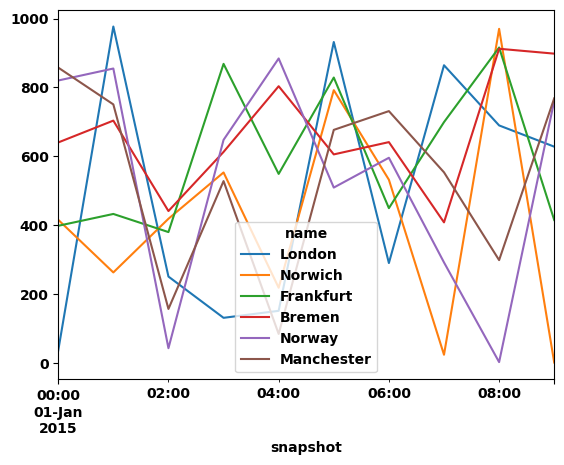

In [33]:
network.loads.dynamic.p_set.plot()

In [34]:
network.global_constraints.static

,type,investment_period,bus,carrier_attribute,sense,constant,mu
name,,,,,,,
co2_limit,primary_energy,NaN,,co2_emissions,<=,1000.0,0.0


In [35]:
network.sub_networks.static

,carrier,slack_bus,obj
name,,,
0,AC,Manchester,<pypsa.networks.SubNetwork object at 0x0000022...
1,DC,Norwich DC,<pypsa.networks.SubNetwork object at 0x0000022...
2,AC,Frankfurt,<pypsa.networks.SubNetwork object at 0x0000022...
3,AC,Norway,<pypsa.networks.SubNetwork object at 0x0000022...


In [36]:
network.sub_networks.static.loc['0','obj']

In [37]:
network.sub_networks.static.loc['0','obj'].components.buses.static

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,country
name,,,,,,,,,,,,,,
London,380.0,,-0.13,51.50,AC,,,1.0,0.0,inf,PQ,,0,UK
Norwich,380.0,,1.30,52.60,AC,,,1.0,0.0,inf,PQ,,0,UK
Manchester,380.0,,-2.20,53.47,AC,,,1.0,0.0,inf,Slack,Manchester Wind,0,UK


Solve the model

In [38]:
network.optimize()

C:\Users\PriyeshGosai\AppData\Local\Temp\ipykernel_63428\2459198637.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize()
Index(['2', '3', '4'], dtype='object', name='name')
Index(['0', '1', '5', '6'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.09s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 188 primals, 468 duals
Objective: -3.47e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, Link-ext-p-lower, Link-ext-p-upper, Kirchhoff-Voltage-Law were not assigned to

('ok', 'optimal')

View all the constraints

In [39]:
network.model

Linopy LP model

Variables:
----------
 * Generator-p_nom (name)
 * Line-s_nom (name)
 * Link-p_nom (name)
 * Generator-p (snapshot, name)
 * Line-s (snapshot, name)
 * Link-p (snapshot, name)
 * objective_constant

Constraints:
------------
 * Generator-ext-p_nom-lower (name)
 * Line-ext-s_nom-lower (name)
 * Link-ext-p_nom-lower (name)
 * Generator-ext-p-lower (snapshot, name)
 * Generator-ext-p-upper (snapshot, name)
 * Line-ext-s-lower (snapshot, name)
 * Line-ext-s-upper (snapshot, name)
 * Link-ext-p-lower (snapshot, name)
 * Link-ext-p-upper (snapshot, name)
 * Bus-nodal_balance (name, snapshot)
 * Kirchhoff-Voltage-Law (snapshot, cycle)
 * GlobalConstraint-co2_limit

Status:
-------
ok

View Results

<Axes: xlabel='snapshot'>

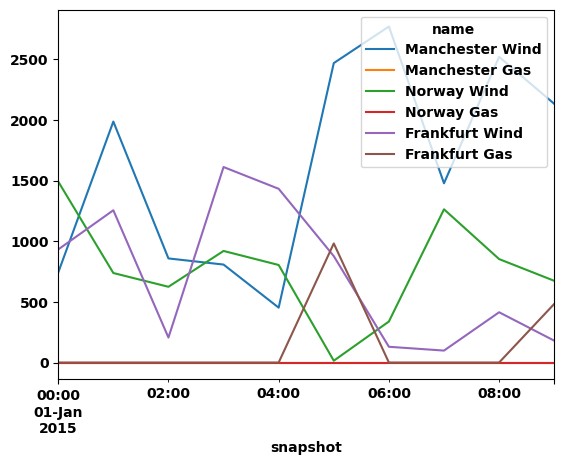

In [40]:
network.generators.dynamic.p.plot()

<Axes: xlabel='snapshot'>

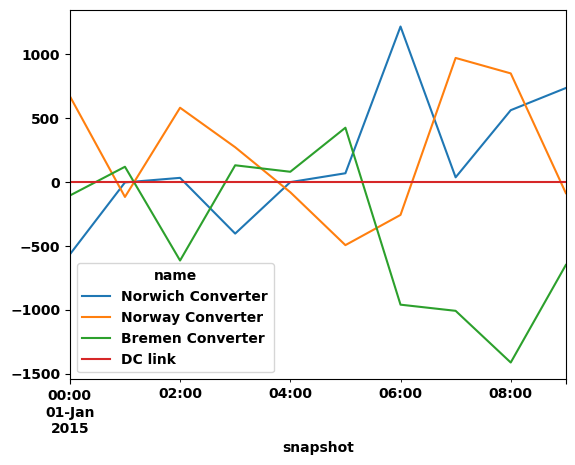

In [41]:
network.links.dynamic.p0.plot()

<Axes: xlabel='snapshot'>

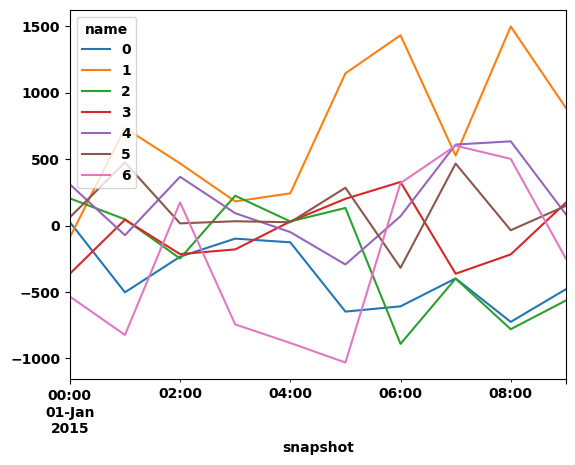

In [42]:
network.lines.dynamic.p0.plot()

Export the results file